In [1]:
import sisl 
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from ase.visualize import view
from mytools.plots import thesis_fig

from matplotlib.ticker import AutoMinorLocator

In [2]:
def showidx(geom):
    x,y,z = geom.xyz.T
    
    fig,ax = plt.subplots()
    ax.scatter(x, y, c='k')
    for atom in range(geom.na):
        ax.annotate(text=atom, xy=(x[atom], y[atom]))
    return fig, ax


In [3]:
labels = ['zigzag', 'armchair']

In [95]:
lab = labels[0]
Nw = 20

outdir = Path(f'./TBT_{lab}')
outdir = Path(f'./TBT-Nw{Nw}-{lab}')
outdir.exists()

True

In [96]:
def get_center_idx(kind, tile):
    """Get the idx of the center-most atom for left and right electrode"""
    num_atoms_uc = 4 # number of atoms in each unit cell (where each unit cell is tiled to give final structure)
    atom_column = num_atoms_uc*tile
    
    if kind == "zigzag": # the electrode is the armchair
        site_offset = -2
    elif kind == "armchair": # the electrode is the zigzag
        site_offset = 3
        
    center_site_left = atom_column // 2
    center_site_right = atom_column // 2 + site_offset
    return center_site_left, center_site_right
        
print(lab)
get_center_idx(lab, 30)

zigzag


(60, 58)

In [97]:
# SEfile = outdir / f'{lab}.TBT.SE.nc'
SEfile = outdir / f'{lab}.TBT.SE.nc'
tbtse = sisl.io.get_sile(SEfile)
En = tbtse.E
kpts = tbtse.k
wk = tbtse.wk
eta = tbtse.eta()
a_dev = tbtse.a_dev

def GetSigma(e, elec=0, k=[0.,0.,0.,]):
    tmp = tbtse.self_energy(elec=elec,E=e,k=k,sort=True).data
    pvt = tbtse.pivot(elec=elec, in_device=True, sort=True).reshape(-1, 1)  # and downfolded to smaller region
    no_d = tbtse.no_d ## down-folded region size
    #print(tmp[0].dtype)
    ZeroMat = 0*np.eye(no_d, dtype=np.complex128)
    Sigma = ZeroMat.copy()  # transform to original orbit
    Sigma[pvt, pvt.T] += tmp  # transform to original orbital-index using pvt arrays.
    return Sigma


E = 0.1
E += 0.005
left_se = GetSigma(E, elec=0)
right_se = GetSigma(E, elec=1)

slice(0, 80, 1) slice(80, 160, 1) slice(160, 240, 1)


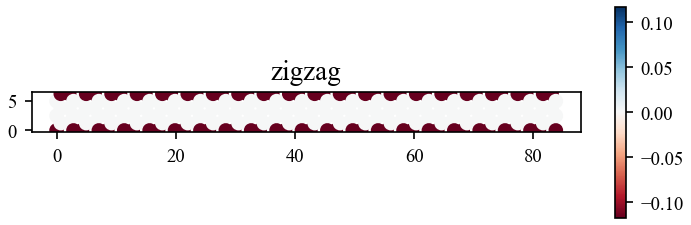

In [98]:
num_atoms = 4 * 10
ND = tbtse.na
NL = tbtse.na_down(0)
NR = tbtse.na_down(1)
idxL = slice(NL//2-num_atoms, NL//2+num_atoms, 1)
idxD = slice(ND//2-num_atoms, ND//2+num_atoms, 1)
idxR = slice(ND-NR//2-num_atoms, ND-NR//2+num_atoms, 1)
print(idxL, idxD, idxR)
xyz = tbtse.xyz

E = 0.
E += 0.005
kpts = [0., 0., 0.]
site0 = NL//2
site1 = ND-NR//2
coup0 = np.imag(GetSigma(e=E, elec=0, k=kpts))
coup1 = np.imag(GetSigma(e=E, elec=1, k=kpts))

vmax = np.max(np.abs([coup0, coup1]))
vmin = -vmax
cmap='RdBu'
fig, ax = plt.subplots(dpi=150)
ax.set_title(lab)
ax.scatter(x=xyz[idxL, 0], y=xyz[idxL, 1], label='left', c=np.diag(coup0)[idxL], vmin=vmin, vmax=vmax, cmap=cmap)
sc=ax.scatter(x=xyz[idxD, 0], y=xyz[idxD, 1], label='device', c=np.zeros(shape=(2*num_atoms)), vmin=vmin, vmax=vmax, cmap=cmap)
ax.scatter(x=xyz[idxR, 0], y=xyz[idxR, 1], label='Right', c=np.diag(coup1)[idxL], vmin=vmin, vmax=vmax, cmap=cmap)

fig.colorbar(sc)
ax.set_aspect('equal')

slice(20, 60, 1) slice(100, 140, 1) slice(180, 220, 1)
80 240 80
(80, 80)
range(38, 58, 4)


warn:0: SislWarning: tbtsencSileTBtrans requesting energy 1.00500 eV, found 0.99500 eV as the closest energy!
warn:0: SislWarning: tbtsencSileTBtrans requesting energy 1.00500 eV, found 0.99500 eV as the closest energy!
warn:0: SislWarning: tbtsencSileTBtrans requesting energy 1.00500 eV, found 0.99500 eV as the closest energy!
warn:0: SislWarning: tbtsencSileTBtrans requesting energy 1.00500 eV, found 0.99500 eV as the closest energy!


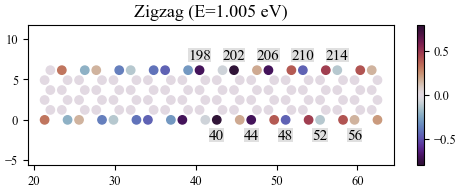

In [224]:
atoms_per_uc = 4
num_uc = 5
num_neighbours = 5
num_atoms = num_uc * atoms_per_uc
ND = tbtse.na
NL = tbtse.na_down(0)
NR = tbtse.na_down(1)
idxL = slice(NL//2-num_atoms, NL//2+num_atoms, 1)
idxD = slice(ND//2-num_atoms, ND//2+num_atoms, 1)
idxR = slice(ND-NR//2-num_atoms, ND-NR//2+num_atoms, 1)
xyz = tbtse.xyz
print(idxL, idxD, idxR)
print(NL, ND, NR)

if lab == 'zigzag':
    site1_offset = +2
elif lab == 'armchair':
    site1_offset = 3

E = 1
E += 0.005
kpts = [0., 0.0, 0.]
site0 = NL//2 - 0 
site1 = ND-NR//2 + site1_offset
# site1 = ND-NR//2 +3
coup0 = np.imag(GetSigma(e=E, elec=0, k=kpts))
coup1 = np.imag(GetSigma(e=E, elec=1, k=kpts))
print(coup0.shape)
Broadening = np.zeros(shape=(ND, ND), dtype=np.complex128)
Broadening[idxL, idxL] += GetSigma(e=E, elec=0, k=kpts)[idxL, idxL]
Broadening[idxR, idxR] += GetSigma(e=E, elec=1, k=kpts)[idxL, idxL]

# vmax = np.max(np.abs([coup0, coup1]))
# vmin = -vmax
vmax = np.max(np.abs([coup0[idxL, site0], coup1[idxL, site0 + site1_offset]]))
vmin = -vmax
cmap='twilight_shifted'
fig, ax = plt.subplots()
ax.set_title(lab.capitalize() + f' (E={E:.3f} eV)')
sc = ax.scatter(x=xyz[idxL, 0], y=xyz[idxL, 1], label='left', c=coup0[idxL, site0], vmin=vmin, vmax=vmax, cmap=cmap)
ax.scatter(x=xyz[idxD, 0], y=xyz[idxD, 1], label='device', c=np.zeros(shape=(2*num_atoms)), vmin=vmin, vmax=vmax, cmap=cmap)
sc = ax.scatter(x=xyz[idxR, 0], y=xyz[idxR, 1], label='Right', c=coup1[idxL, site0 + site1_offset], vmin=vmin, vmax=vmax, cmap=cmap)
# ax.scatter(x=xyz[:ND//2, 0], y=xyz[:ND//2, 1], c=np.imag(Broadening[:ND//2, site0]), vmin=vmin, vmax=vmax, cmap=cmap)
# sc = ax.scatter(x=xyz[ND//2:, 0], y=xyz[ND//2:, 1], c=np.imag(Broadening[ND//2:, site1]), vmin=vmin, vmax=vmax, cmap=cmap)
fig.colorbar(sc)
# for atom in [site0, site1]:
#     ax.annotate(text=atom, xy=(xyz[atom, :2]))


center_site_left, center_site_right = get_center_idx(lab, Nw)

center_neighbours_left = range(center_site_left, center_site_left + atoms_per_uc*num_neighbours, atoms_per_uc)
center_neighbours_right = range(center_site_right, center_site_right + atoms_per_uc*num_neighbours, atoms_per_uc)
print(center_neighbours_right)

if lab == "zigzag":
    haL = haR = "center"
    vaL = "top"
    vaR = "bottom"
    dx = 0
    dy = 1
elif lab == "armchair":
    vaL = vaR = "center"
    haL = "right"
    haR = "left"
    dx = 1
    dy = 0
    

for site in list(center_neighbours_left):
    # site -= 1
    ax.text(x=xyz[site, 0]-dx, y=xyz[site, 1]-dy, s=site, 
            va=vaL, ha=haL, color="k",
            bbox=dict(edgecolor="none", facecolor="lightgrey", alpha=0.7, pad=0.01)
            )
for site in list(center_neighbours_right):
    # site -= 1
    
    single_atom_column = Nw*atoms_per_uc
    two_columns_atoms = single_atom_column*2
    site += two_columns_atoms
    ax.text(x=xyz[site, 0]+dx, y=xyz[site, 1]+dy, s=site, 
            va=vaR, ha=haR, color="k",
            bbox=dict(edgecolor="none", facecolor="lightgrey", alpha=0.7, pad=0.01)
            )


fig.axes[0].set_aspect('equal', adjustable='datalim')
# ax.axis('square')

In [214]:
rmin = 5
rmax = 33
step = 7

test1 = range(5, 17, 3); print(test1)
test2 = slice(5, 17, 3); print(test2)


m = 40
m = max(rmax, m)
np.arange(1, m)[test1] == np.arange(1, m)[test2]

range(5, 17, 3)
slice(5, 17, 3)


array([ True,  True,  True,  True])

# Plotting conv for Siesta calcs

In [327]:
cwd = Path("./")
arm_dir = list(cwd.parent.glob("TBT-Nw*-armchair"))
zig_dir = list(cwd.parent.glob("TBT-Nw*-zigzag"))

def GetSE(file, E=0,
        elec=0,
        k=[0.0, 0.0, 0.0]):
    tmp = file.self_energy(elec=0, E=E, k=k, sort=True).data
    pvt = file.pivot(elec=elec, in_device=True, sort=True).reshape(-1, 1)
    no_d = file.na_d
    Sigma = np.zeros((no_d, no_d), dtype=np.complex128)
    Sigma[pvt, pvt.T] += tmp
    return Sigma


E = 0.5
E += 0.005
kpts = [0., 0., 0.]


nZ = []
nA = []
ZonL_A = []
ZonL_B = []
ZonR_A = []
ZonR_B = []
AonL = []
AonR = []
for zig in zig_dir:
    n = int(str(zig).split('-')[1][2:])
    nZ.append(n)
    seZ = sisl.io.get_sile(zig / 'zigzag.TBT.SE.nc')
    nd = seZ.na
    nl = seZ.na_down(0)
    nr = seZ.na_down(1)
    SEL = np.imag(GetSE(seZ, E=E, elec=0, k=kpts))
    SER = np.imag(GetSE(seZ, E=E, elec=1, k=kpts))
    # print(f"zigzag: n={n}, na={4*n*3}, nd={nd}, nl={nl}, nr={nr}")
    center_site_left, center_site_right = get_center_idx("zigzag", n)
    
   
    ZonL_B.append(SEL[center_site_left , center_site_left])
    ZonR_B.append(SER[center_site_right, center_site_right])
    
    center_site_left -= 1
    center_site_right -= 1
    ZonL_A.append(SEL[center_site_left , center_site_left])
    ZonR_A.append(SER[center_site_right, center_site_right])
    

for arm in arm_dir:    
    n = int(str(arm).split('-')[1][2:])
    nA.append(n)
    seA= sisl.io.get_sile(arm / 'armchair.TBT.SE.nc')
    nd = seA.na
    nl = seA.na_down(0)
    nr = seA.na_down(1)
    # print(f"armchair: n={n}, na={4*n*3}, nd={nd}, nl={nl}, nr={nr}")
    SEL = np.imag(GetSE(seA, E=E, elec=0, k=kpts))
    SER = np.imag(GetSE(seA, E=E, elec=1, k=kpts))
    
    center_site_left, center_site_right = get_center_idx("armchair", n)
    AonL.append(SEL[center_site_left, center_site_left])
    AonR.append(SER[center_site_right, center_site_right])


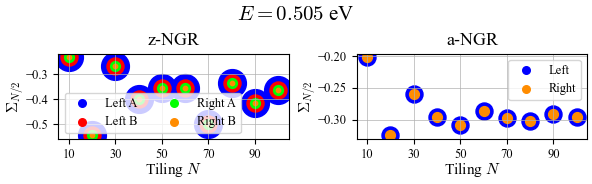

In [328]:
fig, ax = thesis_fig(fraction=1, subplots=(1,2))
ax[0].set_title('z-NGR')
# ax[0].semilogy(nZ, np.abs(ZonL), c='k', linestyle="", marker='o', alpha=0.9, markersize=8)
# ax[0].semilogy(nZ, np.abs(ZonR), c='r', linestyle="", marker='o', alpha=0.9, markersize=2)
ax[0].scatter(nZ, ZonL_A, c='blue', alpha=1, s=400)
ax[0].scatter(nZ, ZonL_B, c='red', alpha=1, s=150)
ax[0].scatter(nZ, ZonR_A, c='lime', alpha=1, s=50)
ax[0].scatter(nZ, ZonR_B, c='darkorange', alpha=1, s=10)
# print(ZonL_A)
ax[0].scatter([], [], c="blue", alpha=1, s=30, label="Left A")
ax[0].scatter([], [], c="red", alpha=1, s=30, label="Left B")
ax[0].scatter([], [], c="lime", alpha=1, s=30, label="Right A")
ax[0].scatter([], [], c="darkorange", alpha=1, s=30, label="Right B")
ax[0].set(xticks=np.sort(nZ)[::2],
        #   ylim=(np.min([ZonL_B, ZonL_A, ZonR_A, ZonR_B])*1.5, np.max([ZonL_B, ZonL_A, ZonR_A, ZonR_B])*0.5),
          xlabel='Tiling $N$',
          ylabel=r'$\Sigma_{N/2}$')
ax[0].grid()

ax[1].set_title('a-NGR')
# ax[1].semilogy(nA, np.abs(AonL), c='k', linestyle="", marker='o', alpha=0.9, markersize=8)
# ax[1].semilogy(nA, np.abs(AonR), c='r', linestyle="", marker='o', alpha=0.9, markersize=2)
ax[1].scatter(nA, AonL, c='blue', alpha=1, s=150)
ax[1].scatter(nA, AonR, c='darkorange', alpha=1, s=50)
ax[1].scatter([], [], c="blue", alpha=1, s=30, label="Left")
ax[1].scatter([], [], c="darkorange", alpha=1, s=30, label="Right")
ax[1].set(xticks=np.sort(nA)[::2],
          xlabel='Tiling $N$',
          ylabel=r'$\Sigma_{N/2}$')
ax[1].grid(True)


ax[0].legend(loc="best", ncols=2)
ax[1].legend(loc="best", ncol=1)

fig.set_constrained_layout(True)
fig.suptitle(f"$E = {E:.3f}$ eV")
fig.savefig('./figures/investigate_edges_onsite_Vs_tiling')

# Coupling

In [329]:
n = 10
center_size_left, center_site_right = get_center_idx("armchair", n)
test = slice(center_site_left,center_site_left + 4*5, 4)

np.arange(0, 320)[test]

array([160, 164, 168, 172, 176])

In [330]:
E = 0.005
kpts = [0., 0., 0.]

num_neighbours = 5
atoms_per_uc = 4

nZ = []
nA = []
ZcoupL_A = []
ZcoupR_A = []
ZcoupL_B = []
ZcoupR_B = []
AcoupL = []
AcoupR = []

# for each dir in the list of dirs named *-zigzag
for zig in zig_dir:
    # get the tiling from the name ans save to list
    n = int(str(zig).split('-')[1][2:])
    nZ.append(n)
    
    # get the self-energy of the left/right electrode
    seZ = sisl.io.get_sile(zig / 'zigzag.TBT.SE.nc')
    # d = seZ.na_d // 2
    SEL = np.imag(GetSE(seZ, E=E, elec=0, k=kpts))
    SER = np.imag(GetSE(seZ, E=E, elec=1, k=kpts))
    
    # get indices of the atom being the center of the left/right electrode
    center_site_left, center_site_right = get_center_idx("zigzag", n)
    # print(np.arange(center_site_left + atoms_per_uc*num_neighbours)[slice(center_site_left, center_site_left + atoms_per_uc*num_neighbours, atoms_per_uc)])
    # print(np.arange(center_site_left + atoms_per_uc*num_neighbours)[slice(center_site_right, center_site_right + atoms_per_uc*num_neighbours, atoms_per_uc)])
    center_neighbours_left = slice(center_site_left, center_site_left + atoms_per_uc*num_neighbours, atoms_per_uc)
    center_neighbours_right = slice(center_site_right, center_site_right + atoms_per_uc*num_neighbours, atoms_per_uc)
    ZcoupL_B.append(SEL[center_site_left, center_neighbours_left])
    ZcoupR_B.append(SER[center_site_right, center_neighbours_right])
    
    
    # see how 
    center_neighbours_left = slice(center_site_left-1, center_site_left-1 + atoms_per_uc*num_neighbours, atoms_per_uc)
    center_neighbours_right = slice(center_site_right-1, center_site_right-1 + atoms_per_uc*num_neighbours, atoms_per_uc)
    ZcoupL_A.append(SEL[center_site_left, center_neighbours_left])
    ZcoupR_A.append(SER[center_site_right, center_neighbours_right])
    
    

ZcoupL_A = np.asarray(ZcoupL_A)
ZcoupR_A = np.asarray(ZcoupR_A)

ZcoupL_B = np.asarray(ZcoupL_B)
ZcoupR_B = np.asarray(ZcoupR_B)



for arm in arm_dir:
    n = int(str(arm).split('-')[1][2:])
    nA.append(n)
    seA= sisl.io.get_sile(arm / 'armchair.TBT.SE.nc')
    # d = seZ.na_d // 2
    SEL = np.imag(GetSE(seA, E=E, elec=0, k=kpts))
    SER = np.imag(GetSE(seA, E=E, elec=1, k=kpts))
    
    center_site_left, center_site_right = get_center_idx("armchair", n)
    center_neighbours_left = slice(center_site_left, center_site_left + atoms_per_uc*num_neighbours, atoms_per_uc)
    center_neighbours_right = slice(center_site_right, center_site_right + atoms_per_uc*num_neighbours, atoms_per_uc)
    AcoupL.append(SEL[center_site_left, center_neighbours_left])
    AcoupR.append(SER[center_site_right, center_neighbours_right])
AcoupL = np.asarray(AcoupL)
AcoupR = np.asarray(AcoupR)
    

In [331]:
ZcoupL_A.shape, np.asarray(nZ).shape

((10, 5), (10,))

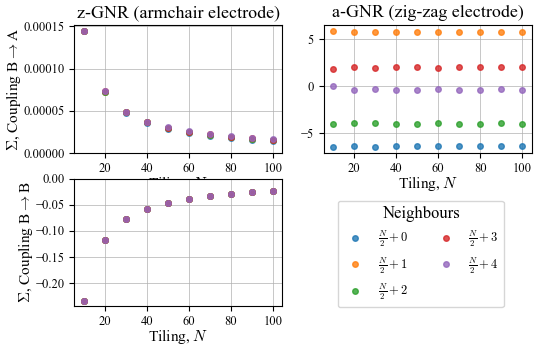

In [468]:

colors = ["blue", "crimson", "lime", "darkorange"]
fig, ax = thesis_fig(subplots=(2,2))

ax[0,0].set_title("z-GNR (armchair electrode)")
ax[0,1].set_title("a-GNR (zig-zag electrode)")


for i in range(num_neighbours):
    ax[0, 0].plot(nZ, ZcoupL_A[:, i], linestyle="none", marker="o", markersize=4, alpha=0.8, label=f"$\\frac{{N}}{{2}}-{i}$")
    
    # ax[0, 0].plot(nZ, ZcoupR_A[:, i], linestyle="none", marker="o", markersize=4)
    
    ax[1, 0].plot(nZ, ZcoupL_B[:, i], linestyle="none", marker="o", markersize=4, alpha=0.8, label=f"$\\frac{{N}}{{2}}-{i}$")
    # ax[1, 0].plot(nZ, ZcoupR_B[:, i], linestyle="none", marker="o", markersize=4)
    
    ax[0,1].plot(nA, (AcoupL[:, i]), linestyle="none", marker="o", markersize=4, alpha=0.8, label=f"$\\frac{{N}}{{2}}-{i}$")

ax[1,1].set_axis_off()
ax[0,0].set(ylabel="$\\Sigma$, Coupling B$\\to$A")
ax[1,0].set(ylabel="$\\Sigma$, Coupling B$\\to$B")
    
for a in ax.flatten():
    if a.axison:
        
        a.grid()
        ymin, ymax = a.get_ylim()
        a.set(ylim=(min(ymin, 0), max(ymax, 0)), xlabel="Tiling, $N$"
            )
    

fig.legend([f"$\\frac{{N}}{{2}} + {i}$" for i in range(num_neighbours)], loc=(0.625, 0.125), ncols=2, title="Neighbours")
        
# fig.set_constrained_layout(True)
# fig.tight_layout()
